# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [40]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
# cargar archivos
plans = pd.read_csv("/datasets/plans.csv")
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [42]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [43]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [44]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [45]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [46]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [47]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [48]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [49]:
# cantidad de nulos para users

print(users.isna().sum())
print(users.isna().sum()*100/4000)


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [50]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().sum()*100/40000)
print(usage['type'].value_counts())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64
text    22092
call    17908
Name: type, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
**Diagnóstico**
  **Users**
  Las columnas city y churn date tienen valores nulos, 11.7% y 88.3% respectivamente.
  -Acción recomendada:
  -city: Crear una nueva categoría "No especificado"
  -churn_date: Crear una nueva columna categórica pra identificar a los usuarios que tengan el plan telefónico activo.
  **Usage**
  Las columnas duracion y length tien una gran cantidad de valores nulos, 55.1% y 44.7% respectivamente.
  -Acción recomendada: Dividir en 2 columnas separadas, ya que solo los mensajes [text] tienen longitud en caractéres [lenght] y solo las llamadas tienen [duracion].
  -Columna para mensajes: Solo registros text con su length
  -Columna para llamadas: Solo registros call con su duration
  
  

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [51]:
# explorar columnas numéricas de users

print(users.describe())
print("Mediana:") 
print(users.median())


            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000
Mediana:
user_id    11999.5
age           47.0
dtype: float64


- La columna `user_id` ... 
La columna user_id no es relevante para el análisis estadístico, ya que funciona únicamente como identificador único. Al no tener valores repetidos, no aporta información para detectar patrones, tendencias o relaciones entre variables.
- La columna `age` ...
La columna presenta una media de 33.73 y una mediana de 47, lo que indica una distribución sesgada, probablemente influenciada por valores atípicos. Destaca un valor mínimo de -9999, que sugiere un código utilizado para representar datos faltantes y no un valor válido.
Por lo tanto, esta columna requiere un proceso de limpieza, incluyendo el tratamiento de valores atípicos y la correcta imputación o eliminación de datos faltantes antes de cualquier análisis.

In [52]:
# explorar columnas numéricas de usage
print(usage.describe())
print("Mediana:") 
print(usage.median())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000
Mediana:
id          20000.5
user_id     12013.0
duration        3.5
length         50.0
dtype: float64


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
La columna user_id no es relevante para el análisis estadístico, ya que funciona únicamente como identificador único. Al no tener valores repetidos, no aporta información para detectar patrones, tendencias o relaciones entre variables.

De igual forma, la columna id tampoco requiere tratamiento, ya que cumple la misma función de identificación única de los registros y no aporta valor analítico directo.
- Las columnas `duration` y `lentgh` deben tratarse de forma separada, ya que corresponden a distintos tipos de evento: `duration` aplica únicamente a llamadas, mientras que `length` se utiliza para mensajes de texto. Por ello, es recomendable segmentar o analizar estas variables en función del tipo de registro.

Tras revisar sus valores mínimos y máximos, no se identifican valores fuera de rango ni inconsistencias aparentes.

In [53]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for columna in columnas_user:
    print(f"Distribución de {columna}:")
    print(users[columna].value_counts())
    print(users[columna].value_counts(normalize=True))
    print("-" * 30)

Distribución de city:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Bogotá      0.228830
CDMX        0.206740
Medellín    0.174455
GDL         0.127443
Cali        0.120079
MTY         0.115265
?           0.027188
Name: city, dtype: float64
------------------------------
Distribución de plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64
------------------------------


- La columna `city`
Hay 96 registros que no se clasifican dentro de ninguna categoría de ciudad, lo que indica la presencia de valores inconsistentes o faltantes que requieren tratamiento.
Por otro lado, Bogotá y CDMX concentran cerca del 50% de los usuarios, por lo que resulta relevante analizar qué factores diferencian a estas ciudades para replicar esas condiciones y fomentar el crecimiento en las demás.
- La columna `plan`
Solo el 35% de los usuarios ha contratado el plan premium, lo que evidencia una baja tasa de adopción. Resulta clave identificar los factores que están limitando su contratación para definir estrategias que impulsen su conversión.

In [54]:
# explorar columna categórica de usage
print(usage['type'].value_counts())
print(usage['type'].value_counts(normalize=True))

text    22092
call    17908
Name: type, dtype: int64
text    0.5523
call    0.4477
Name: type, dtype: float64


- La columna `type`
La distribución de la columna type muestra que los mensajes de texto representan el 55.23% de las interacciones, mientras que las llamadas constituyen el 44.77%. Esto indica una ligera preferencia de los usuarios por la mensajería frente a las llamadas.

Aunque la diferencia no es extrema, sí sugiere un cambio en el comportamiento hacia canales más asincrónicos. Esto puede tener implicaciones en la estrategia del negocio, como priorizar servicios relacionados con mensajería o evaluar la rentabilidad y uso de cada tipo de comunicación.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  En la columna ´age´ y ´city´ de users.
- ¿Qué acción tomarías?
Dado que los valores inválidos de ´age ´representan aproximadamente el 0.24% del total, se considera adecuado eliminarlos, ya que su impacto en el análisis es prácticamente nulo.
Dado que los valores inválidos de ´city´ están representados como “?” y no se cuenta con información adicional para imputarlos correctamente, se opta por reemplazarlos con una categoría “Unknown”. Esto permite conservar los registros sin introducir sesgos artificiales. Alternativamente, dada su baja proporción (0.24%), también podrían eliminarse sin afectar significativamente el análisis.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [55]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [56]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])
usage['date'].dt.year.unique()

array([2024.,   nan])

In [57]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.
En la columna `date` se observan únicamente registros correspondientes al año 2024, lo cual es consistente con las instrucciones del proyecto. Esto indica que se cuenta con información reciente y relevante.
Asimismo, existen valores nulos que representan aproximadamente el 0.125% del total. Dada su baja proporción, se recomienda mantenerlos como nulos, ya que su impacto en el análisis es mínimo.


In [58]:
# Revisar los años presentes en `reg_date` de usage

Los registros abarcan de 2022 a 2026, con ausencia de datos en 2025. Además, la presencia de registros en 2026 resulta inconsistente, ya que corresponde a un periodo futuro.

Estas anomalías —la falta de datos en 2025 y la existencia de fechas futuras— sugieren posibles errores en la captura o procesamiento de la información, por lo que es necesario investigarlas antes de continuar con el análisis.

SyntaxError: invalid syntax (1183529484.py, line 3)

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  En la columna `reg_date` de users hay registros de usuarios en el 2026, pero no el 2025.
  En la columna `date` de usage hay 50 datos nulos.
- ¿Qué harías con ellas?
  Tratar las fechas de 2026 de `reg_date` como valores inválidos y convertirlas a nulos (NaT), ya que representan registros en un periodo futuro. Esto evita introducir supuestos incorrectos y permite un tratamiento posterior más controlado.
  Dado que los valores nulos en la columna `date` representan únicamente el 0.125% del total y se trata de una variable clave para el análisis temporal, se opta por eliminar dichos registros, ya que su impacto en los resultados es insignificante.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [59]:
# Reemplazar -999 por la mediana de age (EXCLUYENDO -999)
users_original = users.copy()

# Calcular mediana solo de valores válidos
age_mediana = users[users['age'] != -999]['age'].median()
print(f"Mediana de edades válidas: {age_mediana}")

users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
print("ANTES del reemplazo:")
print(users_original['age'].describe())
print("\nDESPUÉS del reemplazo:")
print(users['age'].describe())


Mediana de edades válidas: 48.0
ANTES del reemplazo:
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

DESPUÉS del reemplazo:
count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [60]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", "NA")

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
NA           96
Name: city, dtype: int64

In [61]:
# Marcar fechas futuras como NA para reg_date
# Verificar qué años tienes
print(users['reg_date'].dt.year.value_counts().sort_index())
mask_2026 = users['reg_date'].dt.year == 2026
users.loc[mask_2026, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts().sort_index())
print(f"Valores nulos en reg_date: {users['reg_date'].isnull().sum()}")

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64
Valores nulos en reg_date: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [62]:
# Verificación MAR en usage (Missing At Random) para duration
print("Nulos en duration por tipo:")
print(usage.groupby("type")["duration"].apply(lambda x: x.isna().mean()))

Nulos en duration por tipo:
type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [63]:
# Verificación MAR en usage (Missing At Random) para length
print("Nulos en length por tipo:")
print(usage.groupby("type")["length"].apply(lambda x: x.isna().mean()))

Nulos en length por tipo:
type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Los valores faltantes en `duration` y `length` no corresponden a un mecanismo de datos faltantes como MAR o MCAR, sino a valores estructurales no aplicables, determinados por el tipo de interacción (type). Por lo tanto, no requieren imputación y deben analizarse de forma segmentada.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [64]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',           # Total de mensajes
    'is_call': 'sum',           # Total de llamadas  
    'duration': 'sum'           # Total de minutos de llamadas
}).reset_index()

# observar resultado
usage_agg.head(5)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [65]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration':'cant_minutos_llamadas'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamadas
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [66]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage_agg.merge(users,on='user_id',how='left')
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamadas,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [67]:
# Resumen estadístico de las columnas numéricas
#user_profile.info()
colums=["cant_mensajes","cant_llamadas","cant_minutos_llamadas","age"]
for col in colums:
    print("Resumen estadístico de",col,user_profile[col].describe(),"median")
    print(user_profile[col].median())

Resumen estadístico de cant_mensajes count    3999.000000
mean        5.524381
std         2.358416
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64 median
5.0
Resumen estadístico de cant_llamadas count    3999.000000
mean        4.478120
std         2.144238
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
Name: cant_llamadas, dtype: float64 median
4.0
Resumen estadístico de cant_minutos_llamadas count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: cant_minutos_llamadas, dtype: float64 median
19.78
Resumen estadístico de age count    3999.000000
mean       48.138285
std        17.691541
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64 media

In [68]:
# Distribución porcentual del tipo de plan
print("Distribución porcentual del tipo de plan")
user_profile['plan'].value_counts(normalize=True)*100

Distribución porcentual del tipo de plan


Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

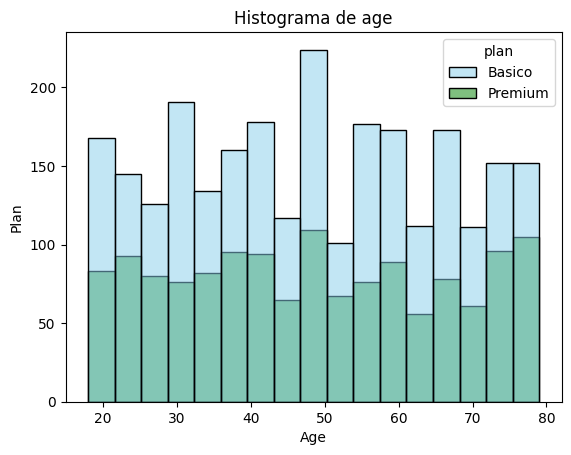

In [69]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])

plt.title('Histograma de age')
plt.xlabel('Age')
plt.ylabel('Plan')
plt.show()



💡Insights: 
La distribución de edad es consistente el 50% de los usuarios son adultos entre los 33 a 63 años y no muestra diferencias significativas entre usuarios de plan básico y premium, lo que sugiere que la edad, por sí sola, no es una variable determinante en la elección del plan.

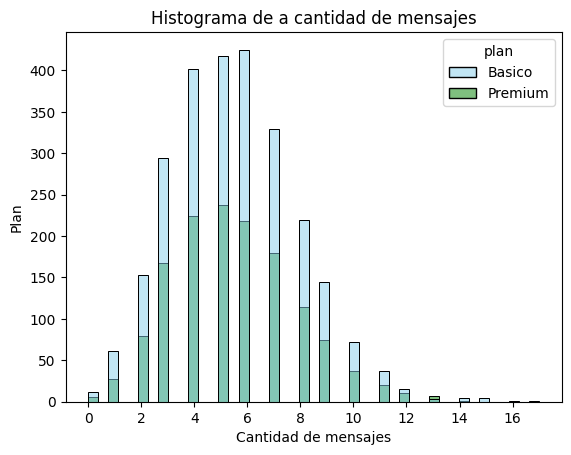

In [70]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.xticks(range(0,18,2))
plt.title('Histograma de a cantidad de mensajes')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Plan')
plt.show()



💡Insights: 
Los usuarios del plan premium envían, en promedio, una mayor cantidad de mensajes en comparación con los del plan básico, lo cual es consistente con los beneficios adicionales que ofrece este plan. Asimismo, la mayor concentración de usuarios se encuentra en el rango de 5 a 6 mensajes, indicando un patrón de uso relativamente moderado. 
Se identifican algunos valores atípicos correspondientes a usuarios que envían más de 11 mensajes; sin embargo, representan un grupo reducido (menos de 50 usuarios).

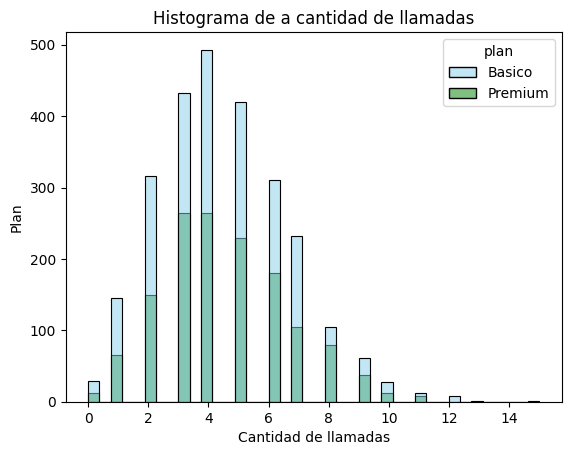

In [71]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Histograma de a cantidad de llamadas')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Plan')
plt.show()



💡Insights: 

Los usuarios del plan premium realizan un número considerablemente mayor de llamadas en comparación con los del plan básico, lo cual podría estar asociado a los beneficios adicionales del plan y al perfil de usuarios predominantemente adultos en edad laboral activa. La mayoría de los usuarios se concentra entre 2 y 5 llamadas, lo que sugiere un patrón de uso moderado.
Asimismo, se identifican algunos valores atípicos correspondientes a usuarios que realizan más de 11 llamadas.

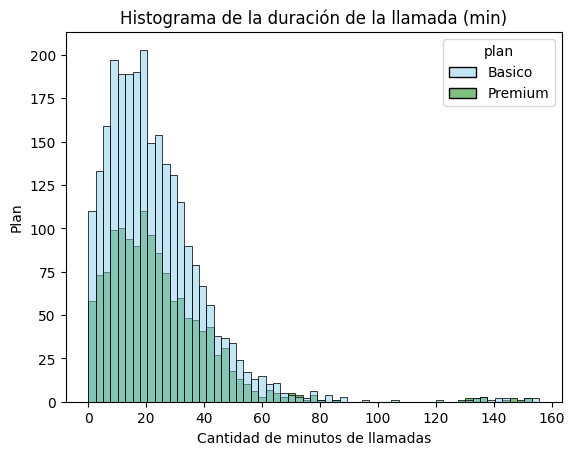

In [72]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamadas', hue='plan', palette=['skyblue', 'green']) 
plt.title('Histograma de la duración de la llamada (min)') 
plt.xlabel('Cantidad de minutos de llamadas') 
plt.ylabel('Plan') 
plt.show()

💡Insights: 
- El histograma presenta un sesgo positivo (hacia la derecha), lo que indica que la mayoría de los usuarios realiza llamadas de corta duración, generalmente por debajo de los 20 minutos (alrededor del 50%). Un 25% adicional se concentra en un rango de entre 30 y 35 minutos, lo que sugiere un segundo grupo de uso moderado.

Asimismo, se identifican valores atípicos con duraciones elevadas, que alcanzan entre 130 y 160 minutos. Finalmente, se observa una mayor participación de usuarios del plan premium en la distribución, lo que podría indicar un mayor nivel de uso en este segmento.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

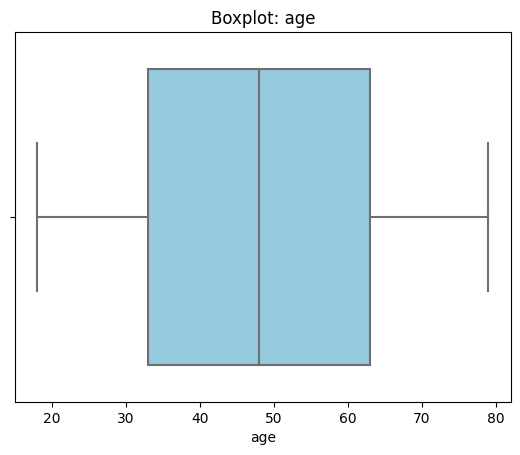

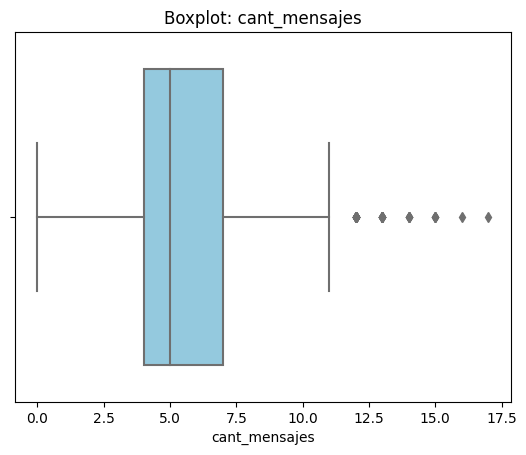

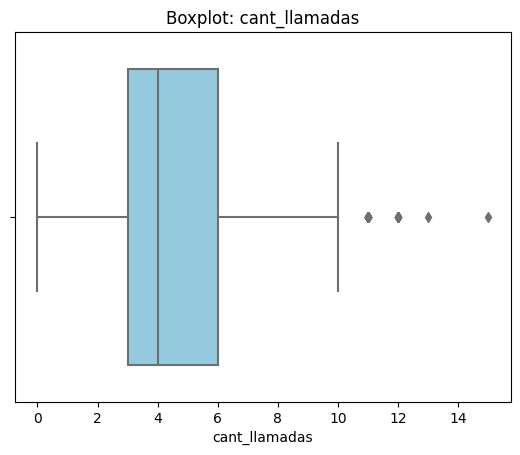

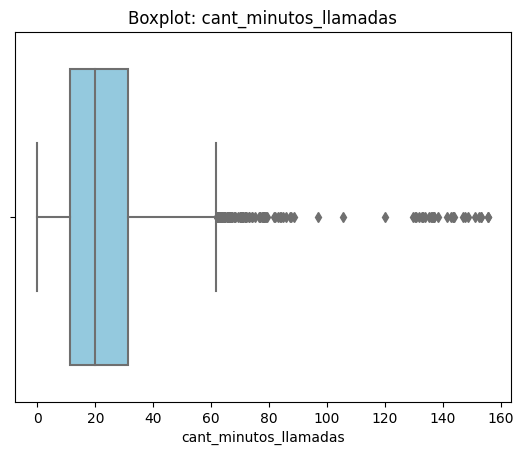

In [80]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamadas']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')  
    plt.title(f'Boxplot: {col}')
    plt.show() 

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: Presenta outliers que van de los 12 a los 18 mensajes 
- cant_llamadas: Presenta pocos outliers que superan las 10 llamadas.
- cant_minutos_llamada: Presenta una gran cantidad de outliers que van desde los 60 hasta los 160 minutos.

In [95]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamadas']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    print('Primer cuartil de: ',col , Q1)

    Q3 = user_profile[col].quantile(0.75)
    print('Tercer cuartil de: ', col , Q3)
    
    IQR = Q3 - Q1
    print('IQR: ', IQR)


Primer cuartil de:  cant_mensajes 4.0
Tercer cuartil de:  cant_mensajes 7.0
IQR:  3.0
Primer cuartil de:  cant_llamadas 3.0
Tercer cuartil de:  cant_llamadas 6.0
IQR:  3.0
Primer cuartil de:  cant_minutos_llamadas 11.12
Tercer cuartil de:  cant_minutos_llamadas 31.415
IQR:  20.295


In [103]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
upper = Q3 + 1.5 * IQR
user_profile['cant_minutos_llamadas'] = user_profile['cant_minutos_llamadas'].clip(upper=upper)
#Identificar valores atípicos
min=Q1-1.5 * IQR #Al ser un valor negativo, no afecta los valores reales
max=Q3+1.5 * IQR 
print("Mínimo:", min)
print("Máximo:", max)

Mínimo: -19.322500000000005
Máximo: 61.8575


In [104]:
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamadas
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,22.532895
std,2.358416,2.144238,14.790722
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,61.857500


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?
  Mientras que la frecuencia de interacción (mensajes y llamadas) es relativamente homogénea entre los usuarios, la duración de las llamadas presenta una        mayor variabilidad, lo que sugiere diferencias más marcadas en la intensidad de uso.
  La variable cant_minutos_llamadas presenta una distribución sesgada hacia valores altos, con una concentración de usuarios en rangos bajos de duración y un grupo reducido con consumos significativamente elevados. Para evitar que estos valores extremos distorsionen el análisis, se aplicó un límite superior basado en el IQR (capping), manteniendo la información relevante sin eliminar registros.
  
Este comportamiento sugiere la existencia de usuarios con patrones de uso intensivo, lo que puede representar un segmento de alto valor para el negocio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [106]:
# Crear columna grupo_uso
import numpy as np

condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

opciones = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')


In [107]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamadas,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [108]:
# Crear columna grupo_edad
condiciones = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

opciones = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones, opciones, default='Adulto Mayor')

In [109]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamadas,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

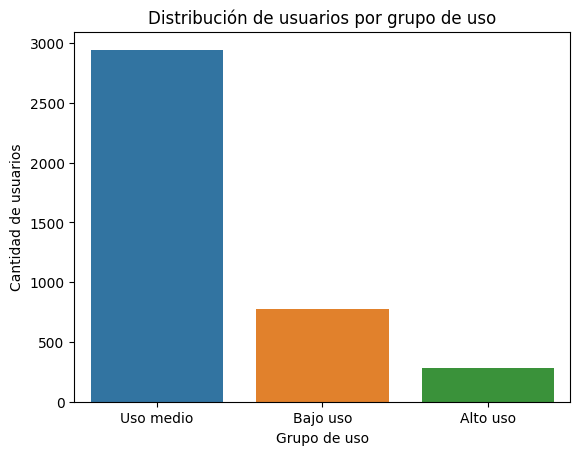

In [111]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', order=user_profile['grupo_uso'].value_counts().index)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()


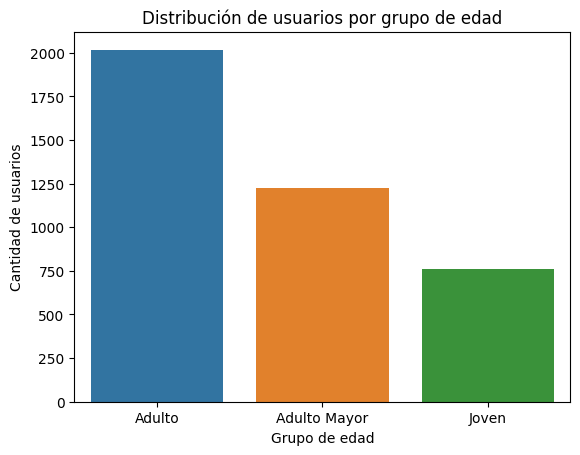

In [112]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', order=user_profile['grupo_edad'].value_counts().index)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**



### Análisis ejecutivo



1. Problemas identificados en los datos

Durante la exploración y limpieza del dataset se detectaron diversos problemas de calidad:

Valores faltantes y registros inválidos
Fechas nulas en date: 0.125% → eliminadas por ser una variable crítica
Edades inválidas: 0.24% → eliminadas por su bajo impacto
Ciudades con valor "?": 96 registros (~0.24%) → tratados como Unknown
Fechas inconsistentes
Registros en 2026 (futuro) y ausencia de datos en 2025 → indicio de errores en captura
Valores atípicos
En cant_minutos_llamadas se detectaron outliers altos (hasta ~160 min)
Valores estructurales (no errores)
Nulos en duration y length dependiendo del tipo (call vs
 text) → correctamente identificados como no aplicables

2. Segmentación de clientes y comportamiento

Se construyeron segmentos basados en nivel de uso:

Bajo uso → <5 llamadas y <5 mensajes
Uso medio → <10 llamadas y <10 mensajes
Alto uso → resto de usuarios
📈 Hallazgos:
La mayoría de los usuarios presenta un uso moderado
La base de clientes está compuesta principalmente por adultos (33–63 años)
La edad no es un factor determinante en la elección de plan (básico vs premium)

3. Segmentos más valiosos

Los usuarios más valiosos identificados son:

Usuarios de alto uso
Mayor número de llamadas y mensajes
Mayor consumo de minutos
Usuarios del plan premium
Mayor intensidad de uso en ambas dimensiones

👉 Estos segmentos generan mayor uso del servicio, lo que puede traducirse en:

Mayor ingreso
Mayor engagement

4. Patrones de uso extremo (outliers)

Se identificaron usuarios con:

Más de 11 llamadas
Más de 11 mensajes
Llamadas de hasta 130–160 minutos
🧠 Interpretación:
No necesariamente son errores
Representan usuarios intensivos (heavy users)
🎯 Implicación:
Son potencialmente clientes de alto valor
Podrían requerir planes diferenciados

5. Recomendaciones estratégicas
📌 1. Optimización de planes
Diseñar planes específicos para:
Usuarios intensivos (mayor capacidad, beneficios premium)
Usuarios de bajo uso (planes más económicos)
📌 2. Estrategia de upselling
Convertir usuarios de uso medio → Premium
Basarse en comportamiento, no en edad
📌 3. Segmentación más precisa
Utilizar variables como:
Minutos consumidos
Frecuencia de uso
Tipo de interacción (call vs text)
📌 4. Monetización de heavy users
Crear planes con:
Minutos ilimitados o extendidos
Meneficios exclusivos
📌 5. Mejora en calidad de datos
Validar captura de fechas (evitar años futuros)
Estandarizar categorías como city
Definir reglas claras para valores faltantes
🎯 Conclusión general

El análisis revela que el comportamiento de uso es el principal diferenciador entre los usuarios, más que variables demográficas como la edad. La existencia de segmentos con uso intensivo representa una oportunidad clara para optimizar la oferta de planes y maximizar el valor del cliente.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`